**Optical flow is used for:**

Finding a correlation between mechanical movement and change of light (image intensity / brightness). The goal is to find a vector which describes the direction and speed with which an point of interest changes. If you calculate this vector for each image point, you get a vectorfunction.

$$
\begin{matrix}
$$

Sometimes illusions occur, when optical flow is detected even though there is no mechanical movement (or vice versa).

# 1. Optical Flow Basics

### How do you calculate it?

**1. Assumption:**
The intensity of a point of interest (POI) stays the same.

$$I(x,y,t)=I(x+\delta x, y+\delta y,t+\delta t) \tag{1}$$

**2. Assumption:**
If you compare two images with each other, then the time step between the two images as well as the change of the POI in x and y direction are small
$$\delta x, \delta y,\delta t$$

then you can use the taylor series approximation which assumes the square of something small is almost zero:
$${\delta x}^2 	\approx {\delta y}^2\approx{\delta t}^2\approx 0$$

to calcualate 
$$I(x + \delta x, y + \delta y, t + \delta t) \approx I(x, y, t) + \frac{\partial I}{\partial x} \delta x + \frac{\partial I}{\partial y} \delta y + \frac{\partial I}{\partial t} \delta t \tag{2}$$

**3. Calculation:** 
Afterwards you can substract $(1)$ from $(2)$ and you get:

$$0=\frac{\partial I}{\partial x} \delta x + \frac{\partial I}{\partial y} \delta y + \frac{\partial I}{\partial t} \delta t \tag{3}$$

This whole equation $(3)$ can be divided by $\delta t$
$$0 = \frac{\partial I}{\partial x} \cdot \frac{\delta x}{\delta t} + \frac{\partial I}{\partial y} \cdot \frac{\delta y}{\delta t} + \frac{\partial I}{\partial t} \tag{4}$$

Now, if you know an optical flow vector exists for each point of the image, which has two components (speed of the POI in x and y direction), you can rewrite the equation $(4)$ using these vector components
$$u = \frac{\delta x}{\delta t}, \quad v = \frac{\delta y}{\delta t}$$

So you finally get the **Optical Flow Constraint Equation**
$$\frac{\partial I}{\partial x} u + \frac{\partial I}{\partial y} v + \frac{\partial I}{\partial t} = 0 \tag{5}$$

Often you see a slightly deviating version of equation $(5)$. Instead of writing the partial derivatives out, the gradients are being used.
$$I_x \cdot u + I_y \cdot v + I_t = 0$$

The three derivatives/gradients can be simply calculated using two images.

**4. Problem:**
Your goal is to calculate two vector components u and v of the optical flow vector but unfortunately you only have one equation $(5)$. Thats why you need (one) more assumption to solve this problem.

- One possible assumption is local smoothness Lucas-Kanade.

- Another possible assumption is global smoothness for Horn-Schunck.


# 2. Lucas Kanade
Lucas & Kanade assumed that the flow is essentially constant in a local neighbourhood of the pixel under consideration, and solved the basic optical flow equations for all the pixels in that neighbourhood, by the least squares criterion.

In a small Patch [e.g. 5×5 pixel around (x, y)] you assume that u and v (the optical flow vectors) are constant.

$$\begin{bmatrix}
I_{x1} & I_{y1} \\
I_{x2} & I_{y2} \\
\vdots & \vdots \\
I_{xn} & I_{yn}
\end{bmatrix}
\cdot
\begin{bmatrix}
u \\
v
\end{bmatrix}
= -
\begin{bmatrix}
I_{t1} \\
I_{t2} \\
\vdots \\
I_{tn}
\end{bmatrix}
$$

Or simply:

$$
A \cdot
\begin{bmatrix}
u \\
v
\end{bmatrix}
= b
$$

Because you want to solve for (u,v), you can use the Least Squares Method:

$$
\begin{bmatrix}
u \\
v
\end{bmatrix}
= (A^T A)^{-1} A^T b
$$

This solution is
+ simple
+ efficient
+ good for small movements

but unfortunately not very robust for 
- large movements
- changes in intensity / brightness
- homogenous regions

In [33]:
# 🔧 Bildpfade anpassen!
I1_path = "../../images/Ball_1.png"
I2_path = "../../images/Ball_2.png"

I1 = load_image_gray(I1_path)
I2 = load_image_gray(I2_path)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, sobel

def load_image_gray(path):
    return np.array(Image.open(path).convert('L'), dtype=np.float32)

def compute_lucas_kanade(I1, I2, window_size=15):
    Ix = sobel(I1, axis=1)
    Iy = sobel(I1, axis=0)
    It = I2 - I1

    u = np.zeros(I1.shape)
    v = np.zeros(I1.shape)

    w = window_size // 2
    for y in range(w, I1.shape[0]-w):
        for x in range(w, I1.shape[1]-w):
            Ix_win = Ix[y-w:y+w+1, x-w:x+w+1].flatten()
            Iy_win = Iy[y-w:y+w+1, x-w:x+w+1].flatten()
            It_win = It[y-w:y+w+1, x-w:x+w+1].flatten()

            A = np.stack((Ix_win, Iy_win), axis=1)
            b = -It_win

            ATA = A.T @ A
            if np.linalg.det(ATA) >= 1e-2:
                nu = np.linalg.inv(ATA) @ A.T @ b
                u[y, x], v[y, x] = nu

    return u, v

# 🌪 Optical Flow berechnen
u, v = compute_lucas_kanade(I1, I2, window_size=15)

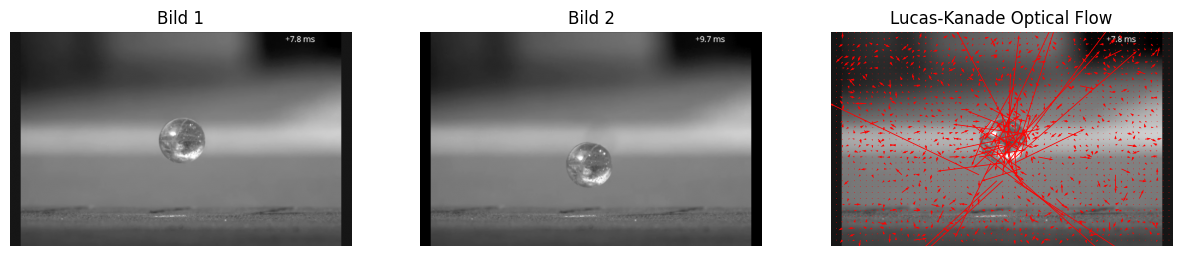

In [36]:
# 🖼️ Darstellung
step = 50
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.imshow(I1, cmap='gray')
plt.title("Bild 1")
plt.axis('off') 

plt.subplot(1, 3, 2)
plt.imshow(I2, cmap='gray')
plt.title("Bild 2")
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(I1, cmap='gray')
plt.quiver(np.arange(0, I1.shape[1], step),
           np.arange(0, I1.shape[0], step),
           u[::step, ::step],
           v[::step, ::step],
           color='r', angles='xy')
plt.title("Lucas-Kanade Optical Flow")
plt.axis('off')
plt.show()

# 3. Horn-Schunck

    It is a global method which introduces a global constraint of smoothness. 
Horn and Schunck assumed that neighbouring pixels have similar movements. This assumption is based on the smoothness term, which should be minimized.

$$\left( \frac{\partial u}{\partial x} \right)^2 + \left( \frac{\partial u}{\partial y} \right)^2 + \left( \frac{\partial v}{\partial x} \right)^2 + \left( \frac{\partial v}{\partial y} \right)^2=\|\nabla u\|^2 + \|\nabla v\|^2 = u_x^2 + u_y^2 + v_x^2 + v_y^2$$

Both assumptions (the Optical flow equation and smoothness) are combined into one energy function, which should be minimzed. This makes sense because you minimize the integral of the energy function which is like minimizing the area underneath the integral which is again like minimizing the distance of u and v?

$$E(u,v) = \iint \left( (I_x u + I_y v + I_t)^2 + \alpha^2 (\|\nabla u\|^2 + \|\nabla v\|^2) \right) dx dy \tag{3.1}$$

$\alpha$ is a regularizationparameter which smoothes the image but also makes the edges less sharp for high values (e.g. 10) and keeps more detail but might be griddy for small values (e.g. 0,5)

The solution is calculated iteratively:
1.	Initialize $u = 0, v = 0$
2.	Repeat:
$$u^{(k+1)} = \bar{u}^{(k)} - \frac{I_x (I_x \bar{u}^{(k)} + I_y \bar{v}^{(k)} + I_t)}{\alpha^2 + I_x^2 + I_y^2}$$

$$v^{(k+1)} = \bar{v}^{(k)} - \frac{I_y (I_x \bar{u}^{(k)} + I_y \bar{v}^{(k)} + I_t)}{\alpha^2 + I_x^2 + I_y^2}$$

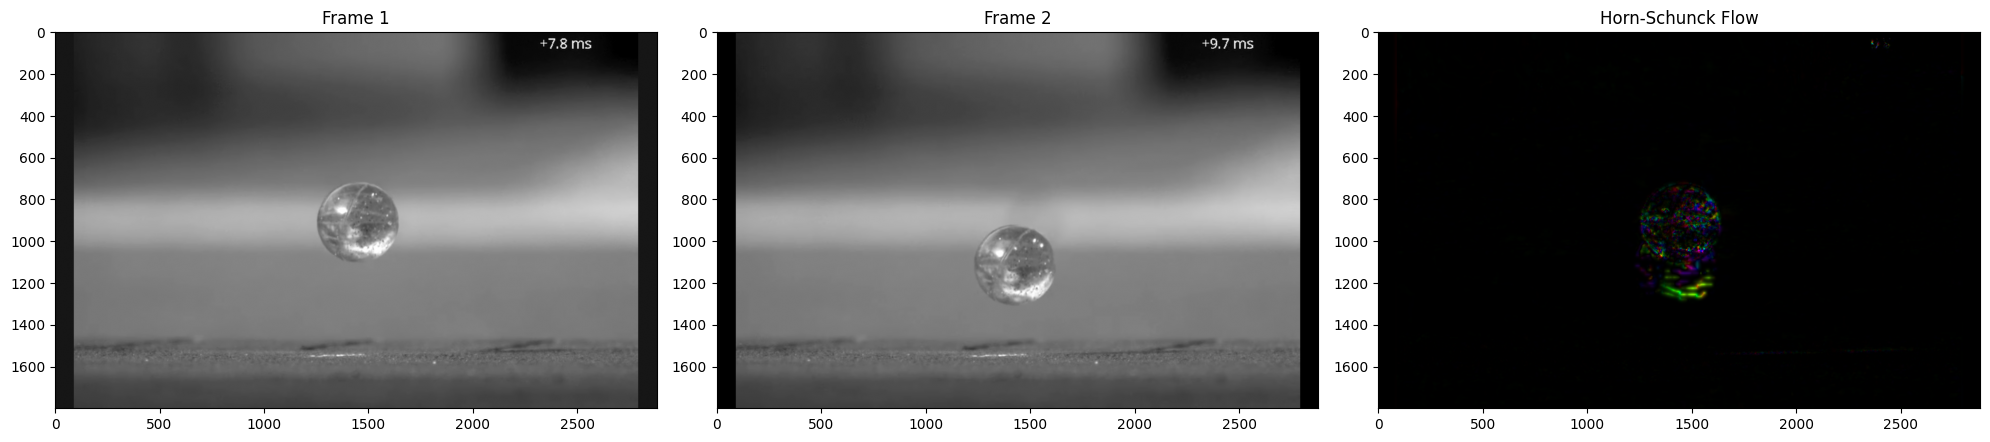

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def compute_derivatives(I1, I2):
    # Sobel-Filter für Ableitungen
    fx = cv2.Sobel(I1, cv2.CV_64F, 1, 0, ksize=5)
    fy = cv2.Sobel(I1, cv2.CV_64F, 0, 1, ksize=5)
    ft = I2.astype(np.float64) - I1.astype(np.float64)
    return fx, fy, ft

def horn_schunck(I1, I2, alpha=1.0, iterations=100):
    I1 = I1.astype(np.float64) / 255.0
    I2 = I2.astype(np.float64) / 255.0
    fx, fy, ft = compute_derivatives(I1, I2)

    u = np.zeros_like(I1)
    v = np.zeros_like(I1)

    # Durchschnittsfilter (Nachbarschaft)
    kernel = np.array([[1/12, 1/6, 1/12],
                       [1/6,   0,  1/6],
                       [1/12, 1/6, 1/12]])

    for _ in range(iterations):
        u_avg = cv2.filter2D(u, -1, kernel)
        v_avg = cv2.filter2D(v, -1, kernel)

        numerator = fx * u_avg + fy * v_avg + ft
        denominator = alpha**2 + fx**2 + fy**2
        u = u_avg - fx * numerator / denominator
        v = v_avg - fy * numerator / denominator

    return u, v

def flow_to_rgb(u, v):
    magnitude = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v, u)
    hsv = np.zeros((u.shape[0], u.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = (angle * 180 / np.pi / 2) % 180
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(magnitude / magnitude.max(), 0, 1) * 255
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

u, v = horn_schunck(I1, I2, alpha=1.0, iterations=200)
flow_rgb = flow_to_rgb(u, v)

# Visualisierung
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.title("Frame 1")
plt.imshow(I1, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Frame 2")
plt.imshow(I2, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("Horn-Schunck Flow")
plt.imshow(flow_rgb)
plt.tight_layout()
plt.show()